### 하이퍼파라미터
* 예측력을 높이기 위해 사용
* 과대/과소 적합을 방지하기 위해 사용
* 사용자가 지정하는 파라미터

#### 하이퍼파라미터 튜닝
* 특정 알고리즘의 매개변수 값을 변경하면서 최적의 파라미터를 찾는 방식
* GridSearchCV클래스를 통해 하이퍼파라미터 탐색과 교차 검증을 한번에 수행

#### GridSearchCV
* 교차 검증으로 하이퍼파라미터 탐색을 수행한다
* 최상의 모델을 찾은 후 훈련 세트 전체를 사용해 최종 모델을 훈련한다
* 매개변수
    - GridSearchCV(모델, param_grid = 파라미터, cv=반복횟수, n_jobs=코어 수(-1, 모든 코어 사용))

### K-최근접 이웃 알고리즘
* 주위에서 가장 가까운 다른 데이터를 보고 현재 데이터를 판단

#### 하이퍼파라미터
* n_neighbors
    - 기본 가까운 5개의 데이터를 보고 자기 자신이 어디에 속하는지를 판단
    - 비교하고자 하는 데이터의 수가 적을 수록 과대 적합이 된다
* metric : 거리계산 척도
    - euclidean(녹색) : 유클리디안 거리 측정
        * 목표 지점까지 가장 짧은 거리
        * 유클리디안은 일반적인 연속형 데이터에 적합
    - manhattan(빨간색) : 맨하튼 거리 측정 방법
        * 찾아가는 경로의 모든 길이의 합
        * 맨하탄 거리는 이상치 영향을 줄이고 싶을 때 사용
* weights : 가중치
    - uniform : 거리에 가중치 부여하지 않음(균일한 가중치)
    - distance : 거리에 가중치 부여(가까이 있는 데이터에 가중치)

In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data_set/5.스케일링/titanic_cleaning.csv")
df.head(2)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,1,0,3,0,22.0,1,0,7.2500
1,2,1,1,1,38.0,1,0,71.2833


In [3]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
       'Fare'],
      dtype='object')

In [4]:
f = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
label = 'Survived'
X, y = df[f], df[label]

In [7]:
minMaxScaler = MinMaxScaler()
minMaxScaler.fit(X)
X_scaler = minMaxScaler.transform(X)
X_scaler

array([[1.        , 0.        , 0.27117366, 0.125     , 0.        ,
        0.01415106],
       [0.        , 1.        , 0.4722292 , 0.125     , 0.        ,
        0.13913574],
       [1.        , 1.        , 0.32143755, 0.        , 0.        ,
        0.01546857],
       ...,
       [1.        , 1.        , 0.36792055, 0.125     , 0.33333333,
        0.04577135],
       [0.        , 0.        , 0.32143755, 0.        , 0.        ,
        0.0585561 ],
       [1.        , 0.        , 0.39683338, 0.        , 0.        ,
        0.01512699]], shape=(891, 6))

In [8]:
# 데이터를 학습용과 테스트용으로 나눈다(train_test_split)
X_train, X_test, y_train, y_test = train_test_split(X_scaler, y, test_size = 0.2)

In [9]:
# k-최근접 이웃 알고리즘
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
print("train : ", knn.score(X_train, y_train))
print("test : ", knn.score(X_test, y_test))

train :  0.8553370786516854
test :  0.8268156424581006


In [16]:
k_param = range(1, 11)
k_param
train_list = []
test_list = []

for k in k_param:
    #print(k)
    knn = KNeighborsClassifier(n_neighbors = k) # k값이 1개일 때 학습, 2개일 때 학습 ~~~ 10개일 때 학습(반복)
    knn.fit(X_train, y_train)
    train_score = knn.score(X_train, y_train)
    test_score = knn.score(X_test, y_test)
    train_list.append(train_score)
    test_list.append(test_score)

In [17]:
print(train_list)
print(test_list)

[0.9775280898876404, 0.8820224719101124, 0.8834269662921348, 0.8665730337078652, 0.8553370786516854, 0.8441011235955056, 0.8455056179775281, 0.8356741573033708, 0.827247191011236, 0.8314606741573034]
[0.7653631284916201, 0.8156424581005587, 0.8212290502793296, 0.8324022346368715, 0.8268156424581006, 0.8379888268156425, 0.8212290502793296, 0.8491620111731844, 0.8491620111731844, 0.8491620111731844]


In [18]:
dic = {
    "k": k_param,
    "train정확도": train_list,
    "test정확도": test_list
}
score_df = pd.DataFrame(dic)
score_df

,k,train정확도,test정확도
0,1,0.977528,0.765363
1,2,0.882022,0.815642
2,3,0.883427,0.821229
3,4,0.866573,0.832402
4,5,0.855337,0.826816
5,6,0.844101,0.837989
6,7,0.845506,0.821229
7,8,0.835674,0.849162
8,9,0.827247,0.849162
9,10,0.831461,0.849162


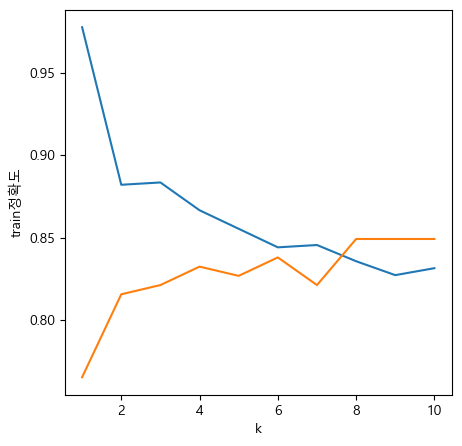

In [20]:
plt.rcParams['font.family'] = 'Malgun Gothic'

fig, ax = plt.subplots(figsize=(5,5))
sns.lineplot(x='k', y='train정확도', data=score_df)
sns.lineplot(x='k', y='test정확도', data=score_df)
plt.show()

In [22]:
params = {
    'n_neighbors':k_param
}
knn = KNeighborsClassifier()
grid_cv = GridSearchCV(knn, param_grid = params, cv = 5, n_jobs = -1) # 교차검증

In [23]:
grid_cv.fit(X_train, y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': range(1, 11)}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,2


In [25]:
# 최상의 파라미터 찾기
grid_cv.best_params_

{'n_neighbors': 2}

In [26]:
print("train score : ", grid_cv.score(X_train, y_train))
print("test score : ", grid_cv.score(X_test, y_test))

train score :  0.8820224719101124
test score :  0.8156424581005587


In [36]:
params = {
    'n_neighbors':k_param,
    'metric': ['manhattan', 'euclidean'],
    'weights':['uniform', 'distance']
}
knn = KNeighborsClassifier()
grid_cv = GridSearchCV(knn, param_grid = params, cv = 5, n_jobs = -1)

In [37]:
grid_cv.fit(X_train, y_train)
print("train score : ", grid_cv.score(X_train, y_train))
print("test score : ", grid_cv.score(X_test, y_test))
grid_cv.best_params_

train score :  0.8806179775280899
test score :  0.8268156424581006


{'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}

In [38]:
knn = KNeighborsClassifier(metric='euclidean', n_neighbors=4, weights='uniform')

In [40]:
knn.fit(X_train, y_train)
print("train score : ", grid_cv.score(X_train, y_train))
print("test score : ", grid_cv.score(X_test, y_test))

train score :  0.8806179775280899
test score :  0.8268156424581006


### svm 하이퍼 파라미터
* C(cost)
    - cost값이 작으면 과소적합이 발생한다.
        * cost값을 작게하면 훈련 데이터에 대해 어느정도 오류를 허용하게 되며, 새로 들어오는 데이터는 잘 분류할 수 있다
    - cost값이 커지면 과대적합이 발생한다.
        * cost값을 크게하면 훈련 데이터에 대해 오류가 최소화 되지만, 새로 들어오는 데이터는 분류를 잘못할 가능성이 높다는 것이다
* gamma (대략적으로 선을 그려 구분한다)
    - 결정 경계에 영향을 끼치는 범위를 조절하는 변수
    - gamma가 크면 과대적합이 될 수 있다
        - gamma가 크면 결정경계에 영향력이 커 결정경계가 복잡해진다
    - gamma가 작으면 과소적합이 될 수 있다.
        - gamma가 작으면 결정경계에 영향력이 미미하여 결정경계가 부드러워진다

In [41]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

In [42]:
df = pd.read_csv("../data_set/5.스케일링/titanic_cleaning.csv")
df.head(2)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,1,0,3,0,22.0,1,0,7.2500
1,2,1,1,1,38.0,1,0,71.2833


In [43]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
       'Fare'],
      dtype='object')

In [44]:
f = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch','Fare']
label = 'Survived'
X, y = df[f], df[label]

In [46]:
scaler = StandardScaler()
scaler.fit(X)
X_scaler = scaler.transform(X)

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X_scaler, y, test_size=0.2)

In [49]:
# 기본 모델
svc = SVC(kernel ="linear")
svc.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [50]:
print("trian score : ", svc.score(X_train, y_train))
print("test score : ", svc.score(X_test, y_test))

trian score :  0.7794943820224719
test score :  0.8156424581005587


In [51]:
# cost 지정
svc = SVC(kernel ="linear", C = 100) # cost 수치 임의로 지정
svc.fit(X_train, y_train)

print("trian score : ", svc.score(X_train, y_train))
print("test score : ", svc.score(X_test, y_test))

trian score :  0.7794943820224719
test score :  0.8156424581005587


In [52]:
param_cost = [0.01, 0.1, 1, 10, 100] # 마진 너비
train_list = []
test_list = []

for cost in param_cost:
    svc = SVC(kernel ="linear", C = cost) #linear: 선형
    svc.fit(X_train, y_train)
    train_list.append(svc.score(X_train, y_train))
    test_list.append(svc.score(X_test, y_test))

In [53]:
dic = {
    "param": param_cost,
    "train정확도":train_list,
    "test정확도":test_list
}
score_df = pd.DataFrame(dic)
score_df

,param,train정확도,test정확도
0,0.01,0.779494,0.815642
1,0.10,0.779494,0.815642
2,1.00,0.779494,0.815642
3,10.00,0.779494,0.815642
4,100.00,0.779494,0.815642


In [56]:
# cost, gamma 지정
param_cost = [0.01, 0.1, 1, 10, 100] # 마진 너비 cost: 경계선 그어줌
param_gamma = [0.001, 0.01, 0.1, 1, 10]
train_list = []
test_list = []

for idx, cost in enumerate(param_cost): # enumerate: 인덱스, 값을 같이 꺼낸다
    svc = SVC(kernel ="rbf", C = cost, gamma = param_gamma[idx]) # rbf: 비선형
    svc.fit(X_train, y_train)
    train_list.append(svc.score(X_train, y_train))
    test_list.append(svc.score(X_test, y_test))

dic = {
    "param": param_cost,
    'param_gamma' : param_gamma,
    "train정확도":train_list,
    "test정확도":test_list
}
score_df = pd.DataFrame(dic)
score_df

,param,param_gamma,train정확도,test정확도
0,0.01,0.001,0.613764,0.625698
1,0.10,0.010,0.779494,0.815642
2,1.00,0.100,0.825843,0.865922
3,10.00,1.000,0.873596,0.804469
4,100.00,10.000,0.932584,0.743017


In [57]:
param_cost = [0.01, 0.1, 1, 10, 100]
param_gamma = [0.001, 0.01, 0.1, 1, 10]

In [58]:
params = {
    "C":param_cost,
    "gamma":param_gamma
}

In [59]:
svc = SVC(kernel="rbf")

In [60]:
#교차 검증
grid_cv = GridSearchCV(svc, param_grid = params, cv =3, n_jobs = -1)

In [61]:
grid_cv.fit(X_train, y_train)
grid_cv.best_params_

{'C': 1, 'gamma': 0.1}

In [62]:
print("train score : ", grid_cv.score(X_train, y_train))
print("test score : ", grid_cv.score(X_test, y_test))

train score :  0.8258426966292135
test score :  0.8659217877094972


### 랜덤 포레스트 하이퍼 파라미터
* n_estimators
    - 트리의 개수. default=10
    - 트리의 개수가 많이면 성능은 좋아지지만, 시간이 오래 걸릴수 있다.
* max_depth
    - 트리의 최대 깊이. default = None
    - 완벽하게 파라미터값이 결정될 때 까지 분할 또는 min_samples_split보다 작아질 때까지 분할
    - 깊이가 깊어지면 과대적합될 수 있으므로 적절히 제어 필요
* min_samples_leaf
    - 맆노드(자식노드가 없는 노드)가 되기 위해 최소한의 샘플 데이터 수
    - min_samples_split과 함께 과대적합 제어용도
    - 불균형 데이터가 있는 경우 작게 설정하는게 좋다
* min_samples_split
    - 노드를 분할하기 위한 최소한의 샘플 데이터수. default = 2
    - 과적합을 제어하는데 사용
    - 작게 설정할 수록 분할 노드가 많아져 과대적합 가능성 증가

In [71]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

In [66]:
df.head(2)
#타이타닉 데이터 셋

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,1,0,3,0,22.0,1,0,7.2500
1,2,1,1,1,38.0,1,0,71.2833


In [68]:
#X, y 타이타닉 데이터
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

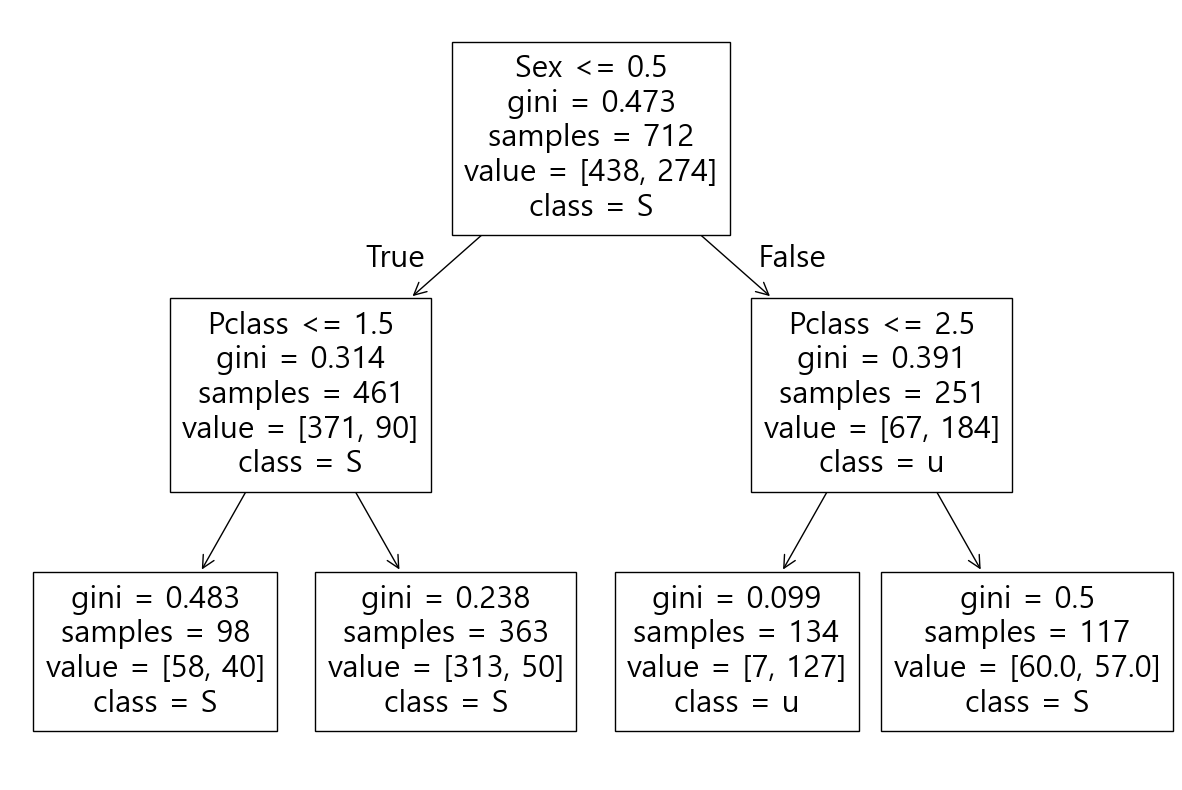

In [73]:
# 트리 시각화
clf = DecisionTreeClassifier(max_depth = 2) #max_depth = 2
clf = clf.fit(X_train, y_train)
fig = plt.figure(figsize=(15,10), facecolor="white")
tree.plot_tree(clf, feature_names=f, class_names=list(label))
plt.show()

In [74]:
rfc = RandomForestClassifier(
    #파라미터 설정
    n_estimators = 100, max_depth=10, min_samples_leaf=4, min_samples_split=100
)
rfc_def = RandomForestClassifier()

In [76]:
# 튜닝한 모델
rfc.fit(X_train, y_train)
print("train: ", rfc.score(X_train, y_train))
print("test: ", rfc.score(X_test, y_test))      

train:  0.8146067415730337
test:  0.8212290502793296


In [77]:
# 기본 모델
rfc_def.fit(X_train, y_train)
print("train: ", rfc_def.score(X_train, y_train))
print("test: ", rfc_def.score(X_test, y_test)) 

train:  0.9873595505617978
test:  0.8044692737430168


In [78]:
params = {
    "n_estimators": range(10,101,10),
    "max_depth": range(4,11,2),
    "min_samples_leaf": range(5,21,5),
    "min_samples_split": range(4,21,4)
}
rfc = RandomForestClassifier()

In [80]:
grid_cv = GridSearchCV(rfc, param_grid = params, cv =3, n_jobs = -1)
grid_cv.fit(X_train, y_train)

,estimator,RandomForestClassifier()
,param_grid,"{'max_depth': range(4, 11, 2), 'min_samples_leaf': range(5, 21, 5), 'min_samples_split': range(4, 21, 4), 'n_estimators': range(10, 101, 10)}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,30


In [81]:
print("최적의 파라미터 : ", grid_cv.best_params_)
print("train : ", grid_cv.score(X_train, y_train))
print("test : ", grid_cv.score(X_test, y_test))

최적의 파라미터 :  {'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 16, 'n_estimators': 30}
train :  0.8778089887640449
test :  0.8324022346368715


In [82]:
df.head(2)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,1,0,3,0,22.0,1,0,7.2500
1,2,1,1,1,38.0,1,0,71.2833


In [83]:
inputData = [[3,0,22.0,1,0,7.2500]]

In [84]:
grid_cv.predict(inputData)

C:\Users\hi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([0])

### 하이퍼파라미터
* n_estimators
    - 학습기의 수 설정.
    - 많으면 예측률은 올라가나 시간이 오래걸릴 수 있음.
* learning_rate
    - GBM이 학습을 진행할 때마다 적용하는 학습률로서 순차적으로 오류 값을 보정해가는 데 적용하는 수 이다
    - 0~1 사이의 값으로 지정한다. default=0.1
    - 너무 작은 값이면 업데이트를 너무 많이 하게 되어 꼼꼼하지만 시간이 오래 걸린다
    - 너무 큰 값이면 최소 오류 값을 찾지 못할 수 있지만 빠르다
* subsample
    - 학습기가 학습에 사용하는 데이터 샘플의 비율(0~1). default=1.
    - 0.5일경우 50%학습데이터를 사용한다는 것이다
    - 과대적합을 줄이려면 작은 값을 적용해야 한다.

In [85]:
from sklearn.ensemble import GradientBoostingClassifier

In [86]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [88]:
gbc = GradientBoostingClassifier()
gbc.fit(X_train, y_train)
print("train : ", gbc.score(X_train, y_train))
print("test : ", gbc.score(X_test, y_test))

train :  0.901685393258427
test :  0.8324022346368715


In [89]:
import numpy as np

In [90]:
params = {
    'learning_rate' : [0.1, 0.3, 0.5, 0.7, 0.9],
    'n_estimators' : [100,300,500],
    'subsample' : np.arange(0.1, 1, 0.2) #실수값은 np 활용
}

In [91]:
grid_cv = GridSearchCV(gbc, param_grid = params, cv=3, n_jobs = -1)

In [93]:
grid_cv.fit(X_train, y_train)

,estimator,GradientBoostingClassifier()
,param_grid,"{'learning_rate': [0.1, 0.3, ...], 'n_estimators': [100, 300, ...], 'subsample': array([0.1, 0....5, 0.7, 0.9])}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


In [94]:
print("최적의 파라미터 : ", grid_cv.best_params_)
print("train : ", grid_cv.score(X_train, y_train))
print("test : ", grid_cv.score(X_test, y_test))

최적의 파라미터 :  {'learning_rate': 0.1, 'n_estimators': 100, 'subsample': np.float64(0.9000000000000001)}
train :  0.9058988764044944
test :  0.8268156424581006


In [96]:
# feature_importances_: 이 모델에서 어떤 칼럼이 중요한지 비율로 보여주는 값
print(gbc.feature_importances_)
X_train.head(1)

[0.14538464 0.4874464  0.14806812 0.03614938 0.00470327 0.17824819]


,Pclass,Sex,Age,SibSp,Parch,Fare
434,1,0,50.0,1,0,55.9
